In [78]:
import numpy as np
import matplotlib.pyplot as plt


In [79]:
import numpy as np
import pyvista as pv
import meshio
import time


class LinearArrayTransducer:
    def __init__(
        self,
        *,
        n_elements,
        element_width_mm,
        element_height_mm,
        kerf_mm,
        elevation_focus_mm,
        no_sub_x,
        no_sub_y,
        frequency_Hz = None
    ):
        """
        Defines a linear array transducer geometry with optional elevation focusing.

        Parameters
        ----------
        n_elements : int
            Number of elements in the array.
        element_width : float
            Width of each element (m).
        element_height : float
            Height of each element (m).
        kerf : float
            Gap between elements (m).
        elevation_focus : float or None
            Elevation focus distance (m). If None, elements are flat.
        no_sub_x, no_sub_y : int
            Number of subdivisions (patches) in x (element width) and y (element height).
            
        """
        start_time = time.time()
        element_height, element_width = element_height_mm / 1000.0, element_width_mm / 1000.0
        kerf, elevation_focus = kerf_mm / 1000.0, elevation_focus_mm / 1000.0
        self.n_elements = n_elements
        self.el_w = element_width
        self.el_h = element_height
        self.kerf = kerf
        self.elev_focus = elevation_focus
        self.no_sub_x = no_sub_x
        self.no_sub_y = no_sub_y
        if frequency_Hz is not None:
            self.fc = frequency_Hz
        else:
            self.fs = 1
            print("Warning: No central frequency provided. Defaulting to 1 Hz.")

        # Per-element apodization weights and delay placeholders
        self.apod = np.ones(n_elements, dtype=float)
        self.delays = np.zeros(n_elements, dtype=float)

        # Compute element centers along x-axis
        total_width = n_elements * element_width + (n_elements - 1) * kerf
        start_x = -total_width / 2 + element_width / 2
        self.element_centers = np.array([
            [start_x + i * (element_width + kerf), 0.0, 0.0]
            for i in range(n_elements)
        ])

        # Build subdivisions boundaries and areas, apply elevation curvature
        self.sub_quad_verts, self.sub_area, self.sub_el_idx = self._build_subdivisions()
        end_time = time.time()
        print(f"Transducer initialized in {end_time - start_time:.4f} seconds.")

    def _build_subdivisions(self):
        """
        Generate vertices for each subdivision quad of each element, applying elevation focus curvature if set.
        Returns
        -------
        sub_quad_verts : list of arrays (4x3) for each patch quad vertices
        sub_area : float, area of each patch
        sub_el_idx : list mapping each patch to its element index
        """
        # Local grid edges in element coordinates
        xs = np.linspace(-self.el_w/2, self.el_w/2, self.no_sub_x + 1)
        ys = np.linspace(-self.el_h/2, self.el_h/2, self.no_sub_y + 1)

        patch_area = (self.el_w / self.no_sub_x) * (self.el_h / self.no_sub_y)

        quads = []
        el_indices = []
        for idx, center in enumerate(self.element_centers):
            for i in range(self.no_sub_x):
                for j in range(self.no_sub_y):
                    # four corners of the patch in local coords
                    corners_local = np.array([
                        [xs[i],   ys[j],   0.0],
                        [xs[i+1], ys[j],   0.0],
                        [xs[i+1], ys[j+1], 0.0],
                        [xs[i],   ys[j+1], 0.0]
                    ])
                    # translate to global x,y
                    corners = corners_local.copy()
                    corners[:,0] += center[0]
                    corners[:,1] += center[1]
                    # apply elevation curvature in z
                    if self.elev_focus is not None and self.elev_focus > 0:
                        y_vals = corners[:,1]
                        z_offset = self.elev_focus - np.sqrt(np.clip(self.elev_focus**2 - y_vals**2, 0, None))
                        corners[:,2] += z_offset
                    else:
                        corners[:,2] += center[2]
                    quads.append(corners)
                    el_indices.append(idx)
        return quads, patch_area, el_indices

    def set_apodization(self, weights):
        """Set per-element apodization weights (length = n_elements)."""
        weights = np.asarray(weights, dtype=float)
        if weights.shape[0] != self.n_elements:
            raise ValueError("Apodization array must match number of elements.")
        self.apod = weights

    def set_delays(self, delays):
        """Set per-element delays in seconds (length = n_elements)."""
        delays = np.asarray(delays, dtype=float)
        if delays.shape[0] != self.n_elements:
            raise ValueError("Delay array must match number of elements.")
        self.delays = delays

    def get_mesh(self):
        """
        Returns a PyVista PolyData mesh of all subdivided quads, with per-cell apodization scalars.
        """
        # Aggregate all points and faces
        verts = []
        faces = []
        scalars = []
        pt_index = 0
        for quad, el_idx in zip(self.sub_quad_verts, self.sub_el_idx):
            # quad is 4x3 array, create face [4, p0, p1, p2, p3]
            verts.extend(quad.tolist())
            face = [4, pt_index, pt_index+1, pt_index+2, pt_index+3]
            faces.append(face)
            scalars.append(self.apod[el_idx])
            pt_index += 4
        # Flatten verts and faces
        verts = np.array(verts)*1e3  # Convert to mm for visualization
        faces_flat = np.hstack(faces)
        mesh = pv.PolyData(verts, faces_flat)
        mesh.cell_data['Apodization'] = np.array(scalars)
        return mesh


In [80]:
test = np.array([1, 2, 3])
print(test.shape)
print(test.ndim)
test = test.reshape((1, 3))
print(test.shape)
print(test.ndim)

(3,)
1
(1, 3)
2


In [81]:
test[:, None, :]

array([[[1, 2, 3]]])

In [91]:
class PyField:
    def __init__(self, transducer):
        """
        Computational framework for ultrasound fields. Wraps a transducer object.
        """
        self.tx = transducer
        self.c = 1540.0  # Speed of sound in soft tissue (m/s)
        self.fs = 100e6 # Sampling frequency (Hz)
        self.t_max = 100e-6  # Max time for field computation

        self.use_attenuation = False  # Flag for attenuation computation
        self.att_f0 = transducer.fc  # Central frequency for attenuation
        self.f_wv = transducer.fc  # Frequency for field computation
        self.lambda_wv = self.c / self.f_wv # Wavelength (um)


        # Frequency independent attenuation at the frequency f0 [dB/m]
        self.att = 0.5  # Attenuation coefficient (dB/m)

    def show_transducer(self, kwargs= None):
        """
        Visualize the transducer surface mesh and apodization with PyVista.
        """
        mesh = self.tx.get_mesh()
        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh,  # Convert to mm for visualization
            scalars='Apodization',
            cmap='viridis',
            show_scalar_bar=True,
            scalar_bar_args={'title':'Apodization', 'vertical': True},
            opacity=1.0,
            show_edges=True,
        )
        plotter.add_axes()
        plotter.show_grid(font_size = 10, xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)", show_zlabels=False)
        plotter.show()

    def spatial_impulse_response(self, field_points):
        """
        Compute the spatial impulse response at given field points.

        Returns
        -------
        t : (T,) array of time samples
        h : (P, T) array of impulse responses
        """
        
        sub_h = self.tx.el_h / self.tx.no_sub_y
        sub_w = self.tx.el_w / self.tx.no_sub_x
        largest_dim = max(sub_h, sub_w)

        if field_points.ndim > 2:
            raise ValueError("Field points must be 3D array (P, 3) or (3,), thus np.array.ndim 2 or 1. np.arrayrray.ndim > 2 is not supported.")
        elif field_points.ndim == 1:
            field_points = field_points.reshape((1, 3))
        
        if field_points.shape[1] != 3:
            raise ValueError("Field points must be 3D array (P, 3) or (3,), thus np.array.ndim 2 or 1. np.array.shape[1] != 3 is not supported.")
        
        distance_point_2_tx = np.linalg.norm(field_points, axis=1)
        min_distance = np.min(distance_point_2_tx)

        criteria = min_distance - largest_dim**2/(4*self.lambda_wv)
        if criteria < 0:
            print("Warning: Field points are too close to the transducer. Results may be inaccurate.")
            print(f"Criteria z - w^2/(4*lambda): {criteria:.2f} m")

        P = field_points.shape[0]
        T = int(np.ceil(self.t_max * self.fs))
        t = np.arange(T) / self.fs
        h = np.zeros((P, T))

        # prepare patch centers
        sub_pos = np.array([quad.mean(axis=0) for quad in self.tx.sub_quad_verts])
        # compute distances and delays
        R = np.linalg.norm(field_points[:, None, :] - sub_pos[None, :, :], axis=2)
        tau = R / self.c
        tau += np.array(self.tx.delays)[np.array(self.tx.sub_el_idx)][None, :]
        samples = np.round(tau * self.fs).astype(int)

        # weights with apodization
        weights = (self.tx.apod[np.array(self.tx.sub_el_idx)] * self.tx.sub_area) / R

        # accumulate impulses
        for pi in range(P):
            for si, n in enumerate(samples[pi]):
                if 0 <= n < T:
                    h[pi, n] += weights[si]
        return t, h

In [96]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.07
element_height_mm = 1.5
elevation_focus_mm = 2  # mm

c = 1540.0  # speed of sound in soft tissue (m/s)


tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    elevation_focus_mm = elevation_focus_mm,
    no_sub_x           = 1,
    no_sub_y           = 5,
    frequency_Hz       = 15.625e6,  # MHz
)

# Apodization and focusing delays
focus_mm = np.array([0, 0, 8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.max() - delays  # time delays for focusing
tx.set_delays(delays)
tx.set_apodization(np.hanning(n_elements))


Transducer initialized in 0.0050 seconds.


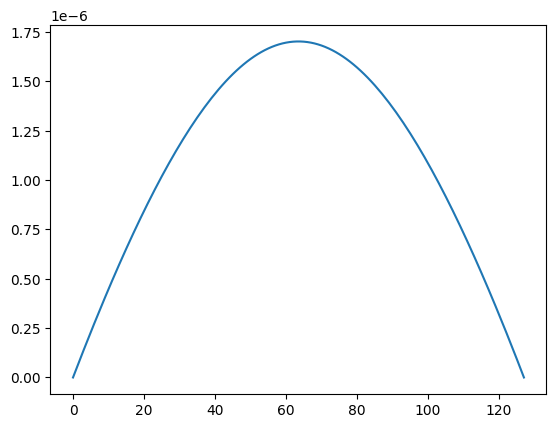

In [97]:
plt.plot(delays, label="Delays")

In [84]:
# Wrap into PyField
field = PyField(tx)
field.show_transducer()

Widget(value='<iframe src="http://localhost:52160/index.html?ui=P_0x2830a162660_15&reconnect=auto" class="pyvi…

In [92]:
t, h = field.spatial_impulse_response(focus_mm*1e-3) 

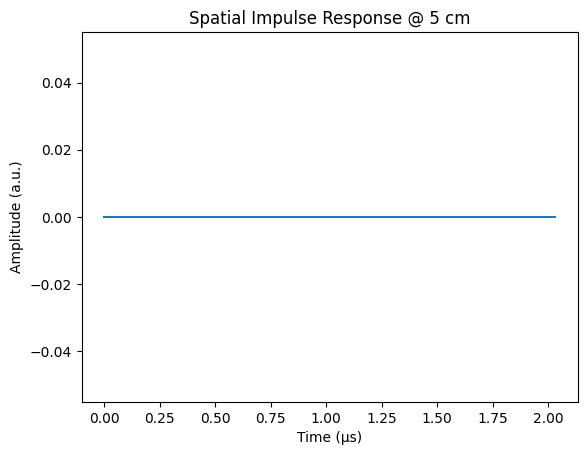

In [94]:
plt.plot(t * 1e6, h[0])
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Spatial Impulse Response @ 5 cm")
plt.show()